# Historical Data Processing and EDA

Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

Principal Component Analysis

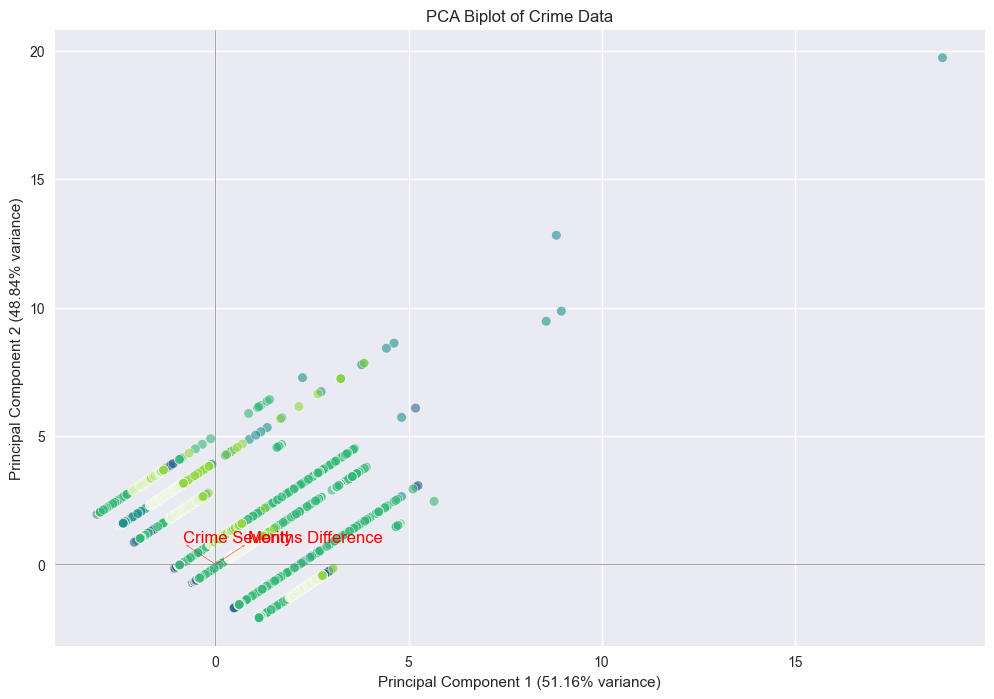

Explained variance by each component: [0.5115906 0.4884094]


In [ ]:
'''
Below script performs Prinicipal Componenet Analysis on cleaned data.
Please refer to the ReadMe file for the relevant changes before running this script
'''

crime_data = pd.read_csv(r'C:\Users\singh\Downloads\EAS508 Project\Historical Data and Preprocessing\Final Files\Final_Crime_Data_With_Severity.csv')
features = ['Months Difference', 'Crime Severity']
data = crime_data.dropna(subset=features)
X = data[features]
y = data['state']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
loadings = pca.components_.T
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.6, legend=False)
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='red', alpha=0.5, head_width=0.05)
    plt.text(loadings[i, 0]*1.2, loadings[i, 1]*1.2, feature, color='red', fontsize=12)
plt.title('PCA Biplot of Crime Data')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}% variance)')
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid(True)
plt.show()
print("Explained variance by each component:", explained_variance)

Principal Component Analysis - Plot with state labels

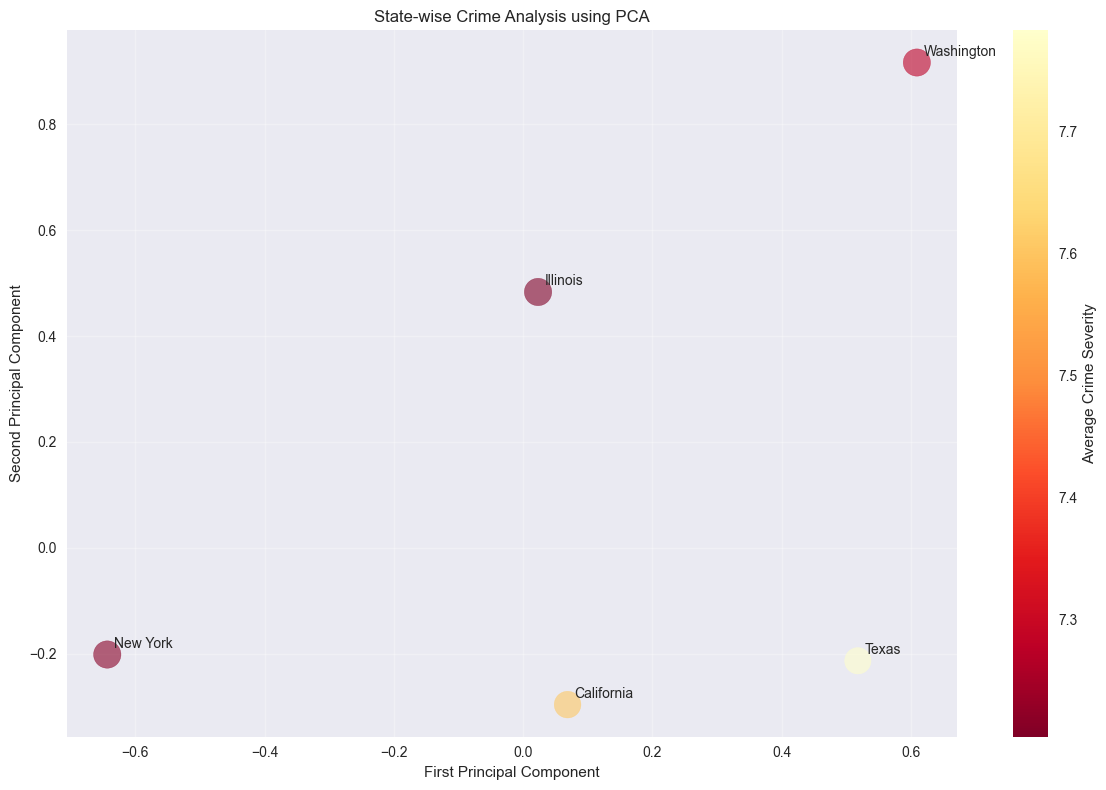

In [ ]:
'''
Below script returns an interpretable PCA plot along with statewise lebels.
Please refer to the ReadMe file for the relevant changes before running this script
'''

data = data.dropna()
X = data[['Crime Severity', 'Months Difference']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['State'] = data['state']
pca_df['Crime Severity'] = data['Crime Severity']
state_means = pca_df.groupby('State', as_index=False)[['PC1', 'PC2', 'Crime Severity']].mean()
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(state_means['PC1'], 
                     state_means['PC2'],
                     s=state_means['Crime Severity']*50,  # Scale size for visibility
                     alpha=0.6,
                     c=state_means['Crime Severity'],
                     cmap='YlOrRd')
inverted_cmap = plt.cm.YlOrRd_r
norm = colors.Normalize(vmin=state_means['Crime Severity'].min(), 
                        vmax=state_means['Crime Severity'].max())
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=inverted_cmap), 
                    ax=ax, label='Average Crime Severity')
for idx, row in state_means.iterrows():
    ax.annotate(row['State'], 
                (row['PC1'], row['PC2']),
                xytext=(5, 5),
                textcoords='offset points')
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('State-wise Crime Analysis using PCA')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Crime severity over time

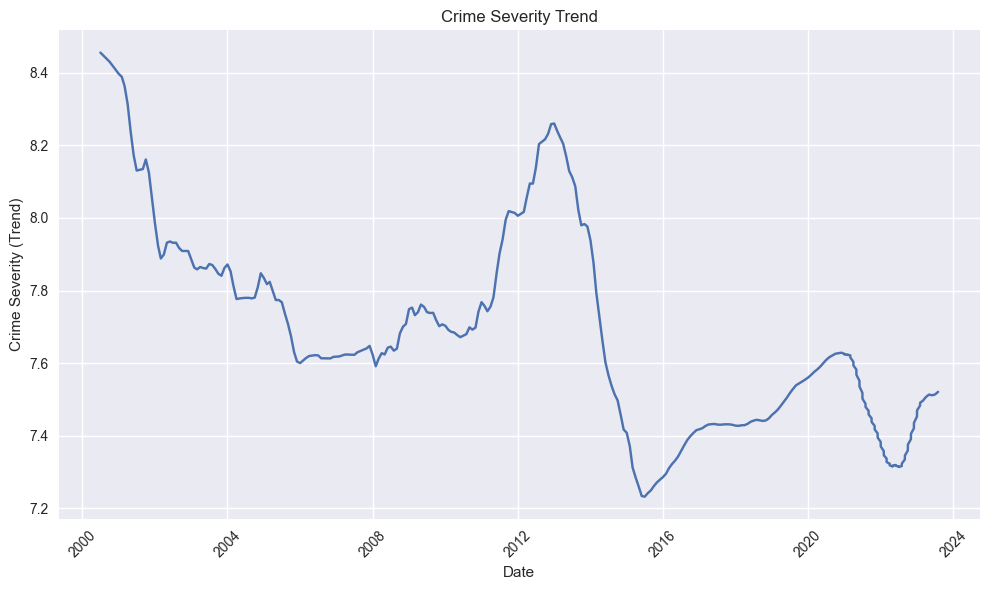

In [ ]:
'''
Below script returns a time series decomposition of crime severity trend.
Please refer to the ReadMe file for the relevant changes before running this script
'''

daily_severity = data.groupby('date')['Crime Severity'].mean()
decomposition = seasonal_decompose(daily_severity, period=30)
plt.figure(figsize=(10, 6))
plt.plot(decomposition.trend)
plt.title('Crime Severity Trend')
plt.xlabel('Date')
plt.ylabel('Crime Severity (Trend)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average crime severity score

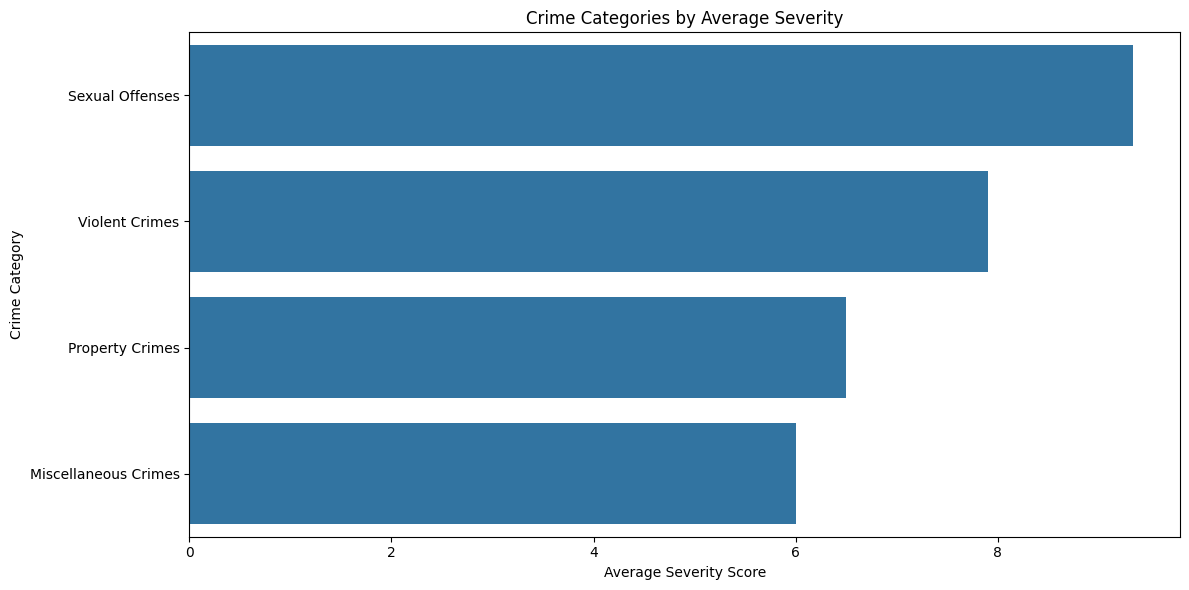

In [ ]:
'''
Below script returns average crime severity score for different crime across all data points.
Please refer to the ReadMe file for the relevant changes before running this script
'''

data['state_severity'] = data.groupby('state')['Crime Severity'].mean()
data['crime_count'] = data.groupby('state')['crime_type'].transform('count')
plt.figure(figsize=(12, 6))
crime_severity = data.groupby('Primary Category')['Crime Severity'].mean().sort_values(ascending=False)
sns.barplot(x=crime_severity.values, y=crime_severity.index)
plt.title('Crime Categories by Average Severity')
plt.xlabel('Average Severity Score')
plt.ylabel('Crime Category')
plt.tight_layout()
plt.show()

State ranking according to crime severity

C:\Users\singh\AppData\Local\Temp\ipykernel_19496\3176616005.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data,


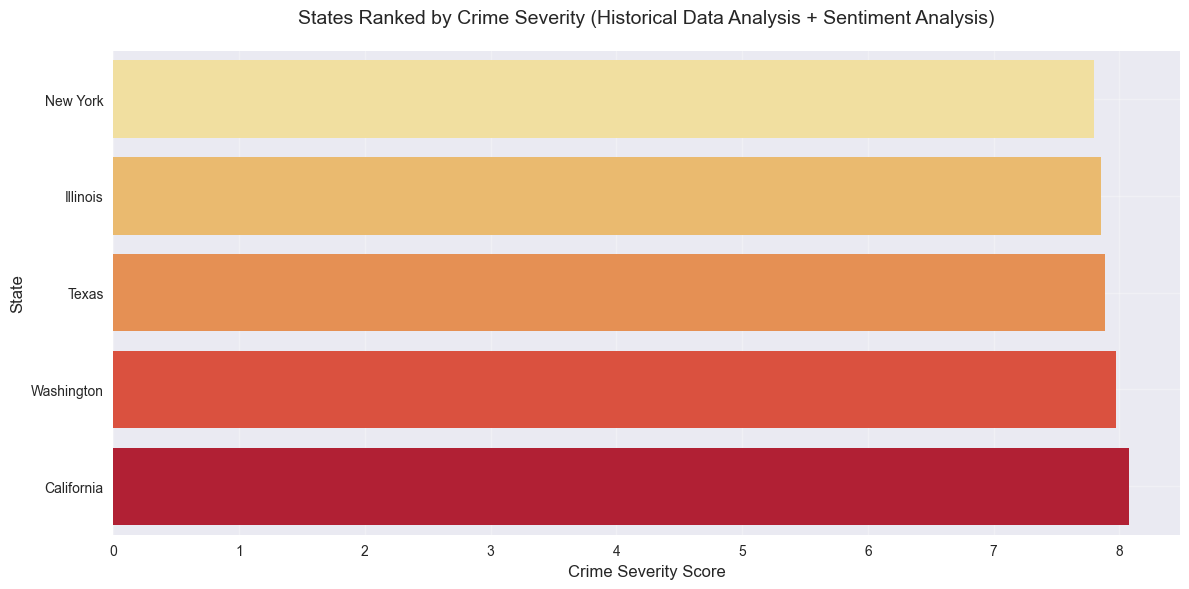

In [ ]:
'''
Below script returns rankings of states as per crime severity scores.
Please refer to the ReadMe file for the relevant changes before running this script
'''

data = pd.DataFrame({
    'State': ['California', 'Illinois', 'New York', 'Texas', 'Washington'],
    'Crime_Severity': [8.0777, 7.8509, 7.7960, 7.8873, 7.9759] #Results derived through average calculations for Sentiment Analysis and Historical Data
})
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12, 6))
sns.barplot(data=data,
            x='Crime_Severity',
            y='State',
            palette='YlOrRd',
            order=data.sort_values('Crime_Severity', ascending=True)['State'])
plt.title('States Ranked by Crime Severity (Historical Data Analysis + Sentiment Analysis)', 
         fontsize=14, 
         pad=20)
plt.xlabel('Crime Severity Score', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
